# Propagation of a Sum of KdV Solitons

This program propagates a sum of solitons of the Korteweg–De Vries equation and demonstrates that the sum does not constitute a soliton exactly, except approximately when the solitons do not overlap.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
def sech(x):
    return 1/np.cosh(x)

## Parameters

In [3]:
L = 80.0                     # Length of water line

NG = 801                     # Number of spatial grid points
dx = L/(NG-1)                # Distance between two grid points
x = np.arange(NG)*dx         

Tmax = 20.0                  # Maximum time
NT = 100001                  # Number of time steps
dt = Tmax/(NT-1)             # Time step
t = np.arange(NT)*dt         # Time grid

## Prepare Grids for Two Soliton Sums

ys1: sum of overlapping solitons
ys2: sum of non-overlapping solitons

In [4]:
ys1 = np.zeros((NT, NG))
ys2 = np.zeros((NT, NG))

## Initial Conditions for Overlapping Solitons

In [5]:
# Initial condition: sum of two overlapping solitons with velocities c1 and c2
c1 = 1.0
c2 = 1.5
ys1[0,:] = 0.5*c1*sech(0.5*np.sqrt(c1)*(x-10))**2 + 0.5*c2*sech(0.5*np.sqrt(c2)*(x-12))**2

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
ys1[1,:] = 0.5*c1*sech(0.5*np.sqrt(c1)*(x-10-c1*dt))**2 + 0.5*c2*sech(0.5*np.sqrt(c2)*(x-12-c2*dt))**2

## Solve the KdV Equation

Update scheme for the sum of solitons:

Finite differences:

$$y_x = y_{i+1}-y_{i-1}$$
$$y_{xxx} = y_{i+2} - 2y_{i+1} + 2y_{i-1} - y_{i-2}$$
$$y_j = y_{j-2} - \frac{dt}{dx} \left(6 y_{j-1} y_x + \frac{y_{xxx}}{dx^2} \right)$$

In [6]:
# Solve the PDE using the finite-difference method
for j in range(2, NT):
    
    yx  = ys1[j-1, 3:NG-1] - ys1[j-1, 1:NG-3]
    
    yx3 = (
        ys1[j-1, 4:NG] 
        - 2*ys1[j-1, 3:NG-1] 
        + 2*ys1[j-1, 1:NG-3] 
        - ys1[j-1, 0:NG-4])
    
    ys1[j, 2:NG-2] = ys1[j-2, 2:NG-2] - (dt/dx)*(6*ys1[j-1, 2:NG-2]*yx + yx3/dx**2)

## Visualization of Overlapping Solitons

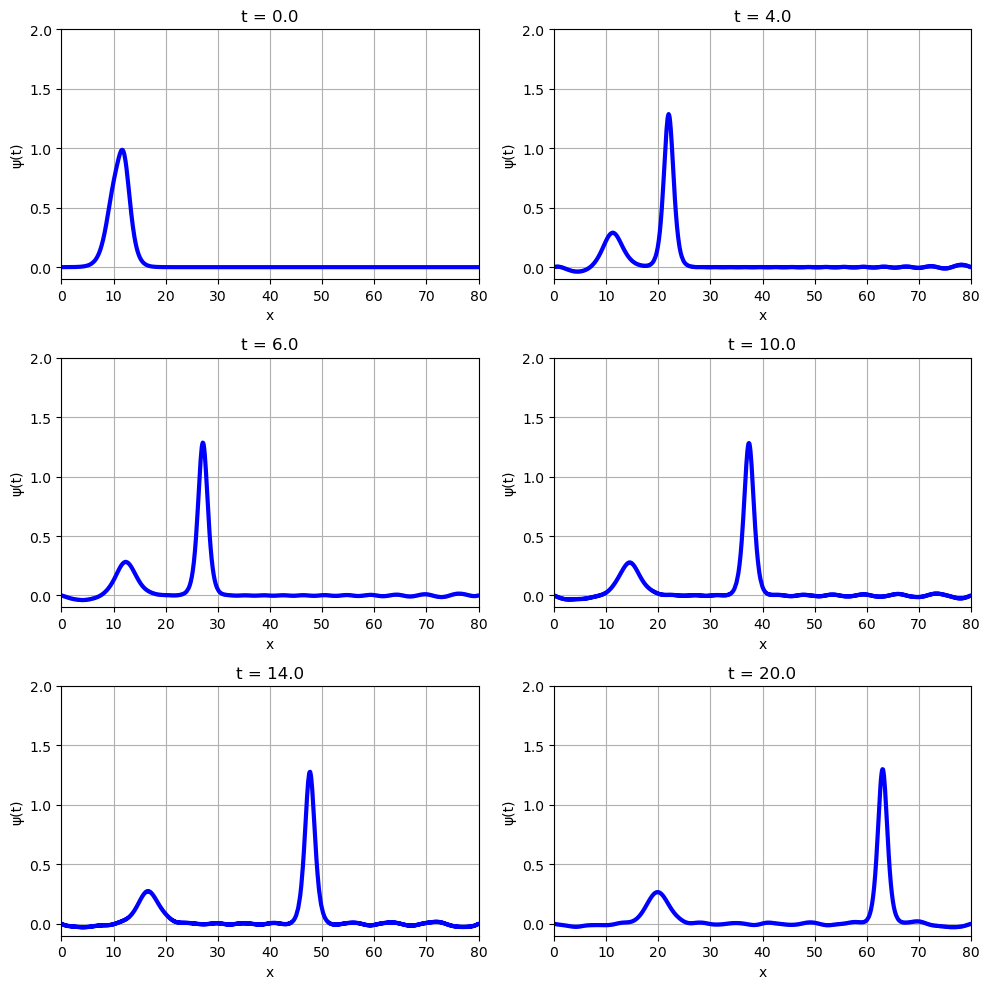

In [7]:
k = [0, 19999, 29999, 49999, 69999, 100000]

plt.figure(figsize=(10,10))
for idx, i in enumerate(k):
    plt.subplot(3,2,idx+1)
    plt.plot(x, ys1[i,:], linewidth=3, color='blue')
    plt.grid(True)
    plt.axis([np.min(x), np.max(x), -0.1, 2])
    plt.xlabel('x')
    plt.ylabel('ψ(t)')
    plt.title(f't = {t[i]:.1f}')
plt.tight_layout()
plt.show()

## Initial Conditions for Non-Overlapping Solitons

In [8]:
# Initial condition: sum of two non-overlapping solitons with velocities c1 and c2
ys2[0,:] = 0.5*c1*sech(0.5*np.sqrt(c1)*(x-10))**2 + 0.5*c2*sech(0.5*np.sqrt(c2)*(x-20))**2
ys2[1,:] = 0.5*c1*sech(0.5*np.sqrt(c1)*(x-10-c1*dt))**2 + 0.5*c2*sech(0.5*np.sqrt(c2)*(x-20-c2*dt))**2

In [9]:
for j in range(2, NT):
    
    yx  = ys2[j-1, 3:NG-1] - ys2[j-1, 1:NG-3]
    
    yx3 = (
        ys2[j-1, 4:NG] 
        - 2*ys2[j-1, 3:NG-1] 
        + 2*ys2[j-1, 1:NG-3] 
        - ys2[j-1, 0:NG-4])
    
    ys2[j, 2:NG-2] = ys2[j-2, 2:NG-2] - (dt/dx)*(6*ys2[j-1, 2:NG-2]*yx + yx3/dx**2)

## Visualization of Non-Overlapping Solitons

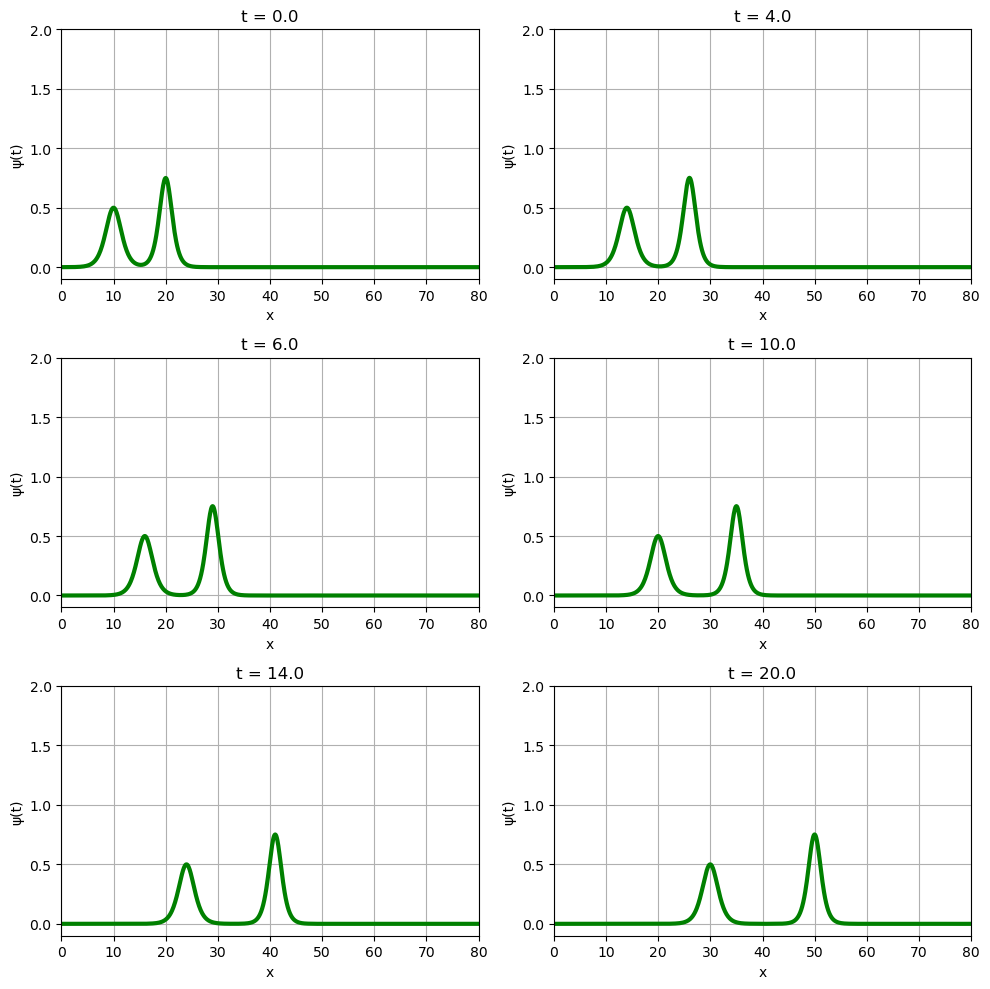

In [10]:
plt.figure(figsize=(10,10))
for idx, i in enumerate(k):
    plt.subplot(3,2,idx+1)
    plt.plot(x, ys2[i,:], linewidth=3, color='green')
    plt.grid(True)
    plt.axis([np.min(x), np.max(x), -0.1, 2])
    plt.xlabel('x')
    plt.ylabel('ψ(t)')
    plt.title(f't = {t[i]:.1f}')
plt.tight_layout()
plt.show()